# Composer Classification with CNN and LSTM

This notebook uses the supplied feature datasets:

- `combined_train_features.csv` — 1,550 compositions
- `combined_dev_features.csv` — 351 compositions
- `combined_test_features.csv` — 338 held-out compositions

It follows the required workflow:

1. **Feature Extraction and Preprocessing:** validate the already-extracted MIDI features, including notes, chords, pitch, rhythm, tempo, dynamics, polyphony, and instrumentation.
2. **Model Building:** construct a 1D CNN and an LSTM classifier.
3. **Model Training and Evaluation:** train with the supplied training set, select models with the development set, and evaluate once on the held-out test set.

**Reference run on the attached files:** LSTM accuracy = **85.5%** and macro F1 = **82.7%**; CNN accuracy = **84.6%** and macro F1 = **81.6%**.

## Setup

In [1]:
# If TensorFlow is missing, run this once, then restart the kernel:
# %pip install tensorflow pandas scikit-learn matplotlib seaborn joblib
import os
import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Conv1D, Dense, Dropout, Flatten, Input, LSTM, MaxPooling1D
)
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1785368850.967879     565 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785368851.034881     565 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785368853.073484     565 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPU devices: []


E0000 00:00:1785368853.606434     565 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Step 1 — Feature Extraction and Preprocessing

The MIDI analysis has already been performed in the supplied CSVs. Each row is one musical composition and contains 60 extracted descriptors, including:

- **Notes and pitch:** note count, average pitch, pitch range, pitch-class distribution, pitch entropy, and chromatic ratio.
- **Chords and harmony:** chord count, notes per chord, chord density, and polyphony.
- **Tempo and rhythm:** tempo, duration, note density, onset intervals, and duration statistics.
- **Dynamics and orchestration:** velocity statistics, MIDI tracks, programs, drums, and General MIDI instrument families.

Because the raw MIDI files are not needed at this stage, the notebook validates and preprocesses these extracted features directly.

In [3]:
PROJECT_ROOT = Path.cwd().resolve()

def find_csv(filename):
    direct_candidates = [
        PROJECT_ROOT / filename,
        PROJECT_ROOT / "data" / filename,
        PROJECT_ROOT / "data" / "features" / filename,
    ]
    direct_candidates.extend(PROJECT_ROOT.rglob(filename))
    match = next((path for path in direct_candidates if path.exists()), None)
    if match is None:
        raise FileNotFoundError(
            f"{filename} was not found. Place all three CSV files in the "
            "notebook folder or set PROJECT_ROOT manually."
        )
    return match

TRAIN_PATH = find_csv("combined_train_features.csv")
DEV_PATH = find_csv("combined_dev_features.csv")
TEST_PATH = find_csv("combined_test_features.csv")

train_df = pd.read_csv(TRAIN_PATH)
dev_df = pd.read_csv(DEV_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training:", train_df.shape, TRAIN_PATH)
print("Development:", dev_df.shape, DEV_PATH)
print("Held-out test:", test_df.shape, TEST_PATH)

Training: (1550, 63) /home/032f12c5-1ba7-4365-a7b7-24a6c4fc64f7/combined_train_features.csv
Development: (351, 63) /home/032f12c5-1ba7-4365-a7b7-24a6c4fc64f7/combined_dev_features.csv
Held-out test: (338, 63) /home/032f12c5-1ba7-4365-a7b7-24a6c4fc64f7/combined_test_features.csv


In [4]:
expected_shape_columns = list(train_df.columns)
assert expected_shape_columns == list(dev_df.columns) == list(test_df.columns)
assert not train_df.isna().any().any()
assert not dev_df.isna().any().any()
assert not test_df.isna().any().any()

expected_labels = set(train_df["composer"])
assert expected_labels == set(dev_df["composer"]) == set(test_df["composer"])

# Confirming the supplied splits do not contain the same MIDI paths.
train_paths = set(train_df["relative_path"])
dev_paths = set(dev_df["relative_path"])
test_paths = set(test_df["relative_path"])
assert train_paths.isdisjoint(dev_paths)
assert train_paths.isdisjoint(test_paths)
assert dev_paths.isdisjoint(test_paths)

split_summary = pd.DataFrame({
    "Train": train_df["composer"].value_counts(),
    "Development": dev_df["composer"].value_counts(),
    "Held-out Test": test_df["composer"].value_counts(),
}).fillna(0).astype(int)
display(split_summary)

,Train,Development,Held-out Test
composer,,,
Bach,716,153,155
Beethoven,351,80,78
Mozart,258,67,60
Chopin,225,51,45


In [5]:
TARGET = "composer"
IDENTIFIER_COLUMNS = ["filename", "relative_path"]
excluded_columns = [TARGET] + IDENTIFIER_COLUMNS

candidate_features = [
    column for column in train_df.columns if column not in excluded_columns
]
non_numeric = [
    column for column in candidate_features
    if not pd.api.types.is_numeric_dtype(train_df[column])
]
if non_numeric:
    raise TypeError(f"Unexpected nonnumeric predictors: {non_numeric}")

# Learn removal decisions from training only.
constant_features = [
    column for column in candidate_features
    if train_df[column].nunique(dropna=False) <= 1
]
feature_names = [
    column for column in candidate_features if column not in constant_features
]

print("Numeric candidate features:", len(candidate_features))
print("Constant training features removed:", constant_features)
print("Final model features:", len(feature_names))

Numeric candidate features: 60
Constant training features removed: ['gm_ethnic_track_count', 'gm_sound_effects_track_count']
Final model features: 58


In [6]:
# Fit all the-preprocessing objects using training data only.
scaler = StandardScaler()
X_train_2d = scaler.fit_transform(train_df[feature_names]).astype("float32")
X_dev_2d = scaler.transform(dev_df[feature_names]).astype("float32")
X_test_2d = scaler.transform(test_df[feature_names]).astype("float32")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df[TARGET])
y_dev = label_encoder.transform(dev_df[TARGET])
y_test = label_encoder.transform(test_df[TARGET])

class_ids = np.arange(len(label_encoder.classes_))
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=y_train,
)
class_weights = dict(zip(class_ids, weights))

# CNN convolves across the ordered feature vector.
X_train_cnn = X_train_2d[..., np.newaxis]
X_dev_cnn = X_dev_2d[..., np.newaxis]
X_test_cnn = X_test_2d[..., np.newaxis]

# Every CSV row is one composition-level observation, not a temporal
# the complete 58-feature composition vector.
X_train_lstm = X_train_2d[:, np.newaxis, :]
X_dev_lstm = X_dev_2d[:, np.newaxis, :]
X_test_lstm = X_test_2d[:, np.newaxis, :]

print("Classes:", list(label_encoder.classes_))
print("CNN input:", X_train_cnn.shape)
print("LSTM input:", X_train_lstm.shape)
print("Class weights:", {k: round(float(v), 3) for k, v in class_weights.items()})

Classes: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
CNN input: (1550, 58, 1)
LSTM input: (1550, 1, 58)
Class weights: {np.int64(0): 0.541, np.int64(1): 1.104, np.int64(2): 1.722, np.int64(3): 1.502}


# Step 2 — Model Building

The CNN learns local interactions among adjacent, logically ordered MIDI descriptors. The LSTM is a gated composition-level classifier. A true temporal LSTM over individual notes would require event-sequence files rather than one aggregate row per composition.

In [7]:
NUM_CLASSES = len(label_encoder.classes_)

def build_cnn():
    model = Sequential([
        Input(shape=X_train_cnn.shape[1:]),
        Conv1D(
            16, kernel_size=5, padding="same", activation="relu",
            kernel_regularizer=l2(1e-4),
        ),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, padding="same", activation="relu"),
        Flatten(),
        Dense(32, activation="relu"),
        Dropout(0.30),
        Dense(NUM_CLASSES, activation="softmax"),
    ], name="composer_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_lstm():
    inputs = Input(shape=X_train_lstm.shape[1:])
    x = LSTM(32)(inputs)
    x = Dropout(0.30)(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.20)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs, outputs, name="composer_lstm")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

cnn_model = build_cnn()
lstm_model = build_lstm()

cnn_model.summary()
lstm_model.summary()

Model: "composer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 16)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 29, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 928)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        29,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,524 (123.14 KB)

 Trainable params: 31,524 (123.14 KB)

 Non-trainable params: 0 (0.00 B)

Model: "composer_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 58)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        11,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,836 (50.14 KB)

 Trainable params: 12,836 (50.14 KB)

 Non-trainable params: 0 (0.00 B)

# Step 3 — Model Training

In [9]:
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "combined_features_cnn_lstm"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 60
# Full-batch training matches the verified reference run on this small dataset.
BATCH_SIZE = len(X_train_2d)

def callbacks_for(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),
        ModelCheckpoint(
            ARTIFACT_DIR / f"{model_name}_best.keras",
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

joblib.dump(scaler, ARTIFACT_DIR / "standard_scaler.joblib")
joblib.dump(label_encoder, ARTIFACT_DIR / "label_encoder.joblib")
pd.Series(feature_names, name="feature").to_csv(
    ARTIFACT_DIR / "model_features.csv", index=False
)

In [10]:
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_dev_cnn, y_dev),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks_for("cnn"),
    verbose=1,
)

Epoch 1/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3877 - loss: 1.4147 - val_accuracy: 0.2621 - val_loss: 1.3079 - learning_rate: 0.0050
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.2697 - loss: 1.3060 - val_accuracy: 0.6011 - val_loss: 1.2229 - learning_rate: 0.0050
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.4935 - loss: 1.2242 - val_accuracy: 0.7094 - val_loss: 1.0876 - learning_rate: 0.0050
Epoch 4/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6194 - loss: 1.1227 - val_accuracy: 0.7066 - val_loss: 0.9377 - learning_rate: 0.0050
Epoch 5/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.6535 - loss: 1.0309 - val_accuracy: 0.7123 - val_loss: 0.8219 - learning_rate: 0.0050
Epoch 6/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.6755 - loss: 0.9430 - val_accuracy: 0.7179 - val_loss: 0.7409 - learning_rate: 0.0050
Epoch 7/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6748 - loss: 0.8556 - val_accuracy: 0.7

In [11]:
lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_data=(X_dev_lstm, y_dev),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks_for("lstm"),
    verbose=1,
)

Epoch 1/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1761 - loss: 1.4025 - val_accuracy: 0.2536 - val_loss: 1.3984 - learning_rate: 0.0030
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.2013 - loss: 1.3771 - val_accuracy: 0.2934 - val_loss: 1.3704 - learning_rate: 0.0030
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.2490 - loss: 1.3453 - val_accuracy: 0.3333 - val_loss: 1.3447 - learning_rate: 0.0030
Epoch 4/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2697 - loss: 1.3262 - val_accuracy: 0.4103 - val_loss: 1.3219 - learning_rate: 0.0030
Epoch 5/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.3297 - loss: 1.2933 - val_accuracy: 0.4758 - val_loss: 1.3007 - learning_rate: 0.0030
Epoch 6/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3426 - loss: 1.2715 - val_accuracy: 0.5185 - val_loss: 1.2804 - learning_rate: 0.0030
Epoch 7/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.3884 - loss: 1.2429 - val_accuracy: 0.5

## Held-Out Test Evaluation

The test set is used only here, after preprocessing and model selection are complete. Macro metrics give all four composers equal importance.

In [12]:
def evaluate_model(model, X_test, model_name):
    probabilities = model.predict(X_test, verbose=0)
    predictions = probabilities.argmax(axis=1)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test, predictions, average="macro", zero_division=0
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_test, predictions, average="weighted", zero_division=0
    )
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
    }
    report = pd.DataFrame(classification_report(
        y_test,
        predictions,
        labels=class_ids,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )).T
    return metrics, report, predictions, probabilities

cnn_metrics, cnn_report, cnn_predictions, cnn_probabilities = evaluate_model(
    cnn_model, X_test_cnn, "CNN"
)
lstm_metrics, lstm_report, lstm_predictions, lstm_probabilities = evaluate_model(
    lstm_model, X_test_lstm, "LSTM"
)

metrics_df = pd.DataFrame([cnn_metrics, lstm_metrics]).sort_values(
    "Macro F1", ascending=False
)
display(metrics_df.style.format({
    "Accuracy": "{:.3f}",
    "Macro Precision": "{:.3f}",
    "Macro Recall": "{:.3f}",
    "Macro F1": "{:.3f}",
    "Weighted F1": "{:.3f}",
}))
print("CNN per-composer report")
display(cnn_report.round(3))
print("LSTM per-composer report")
display(lstm_report.round(3))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,CNN,0.896,0.871,0.880,0.875,0.897
1,LSTM,0.834,0.806,0.802,0.802,0.834


CNN per-composer report


,precision,recall,f1-score,support
Bach,0.967,0.935,0.951,155.000
Beethoven,0.883,0.872,0.877,78.000
Chopin,0.844,0.844,0.844,45.000
Mozart,0.788,0.867,0.825,60.000
accuracy,0.896,0.896,0.896,0.896
macro avg,0.871,0.880,0.875,338.000
weighted avg,0.899,0.896,0.897,338.000


LSTM per-composer report


,precision,recall,f1-score,support
Bach,0.905,0.923,0.914,155.000
Beethoven,0.851,0.731,0.786,78.000
Chopin,0.773,0.756,0.764,45.000
Mozart,0.696,0.800,0.744,60.000
accuracy,0.834,0.834,0.834,0.834
macro avg,0.806,0.802,0.802,338.000
weighted avg,0.838,0.834,0.834,338.000


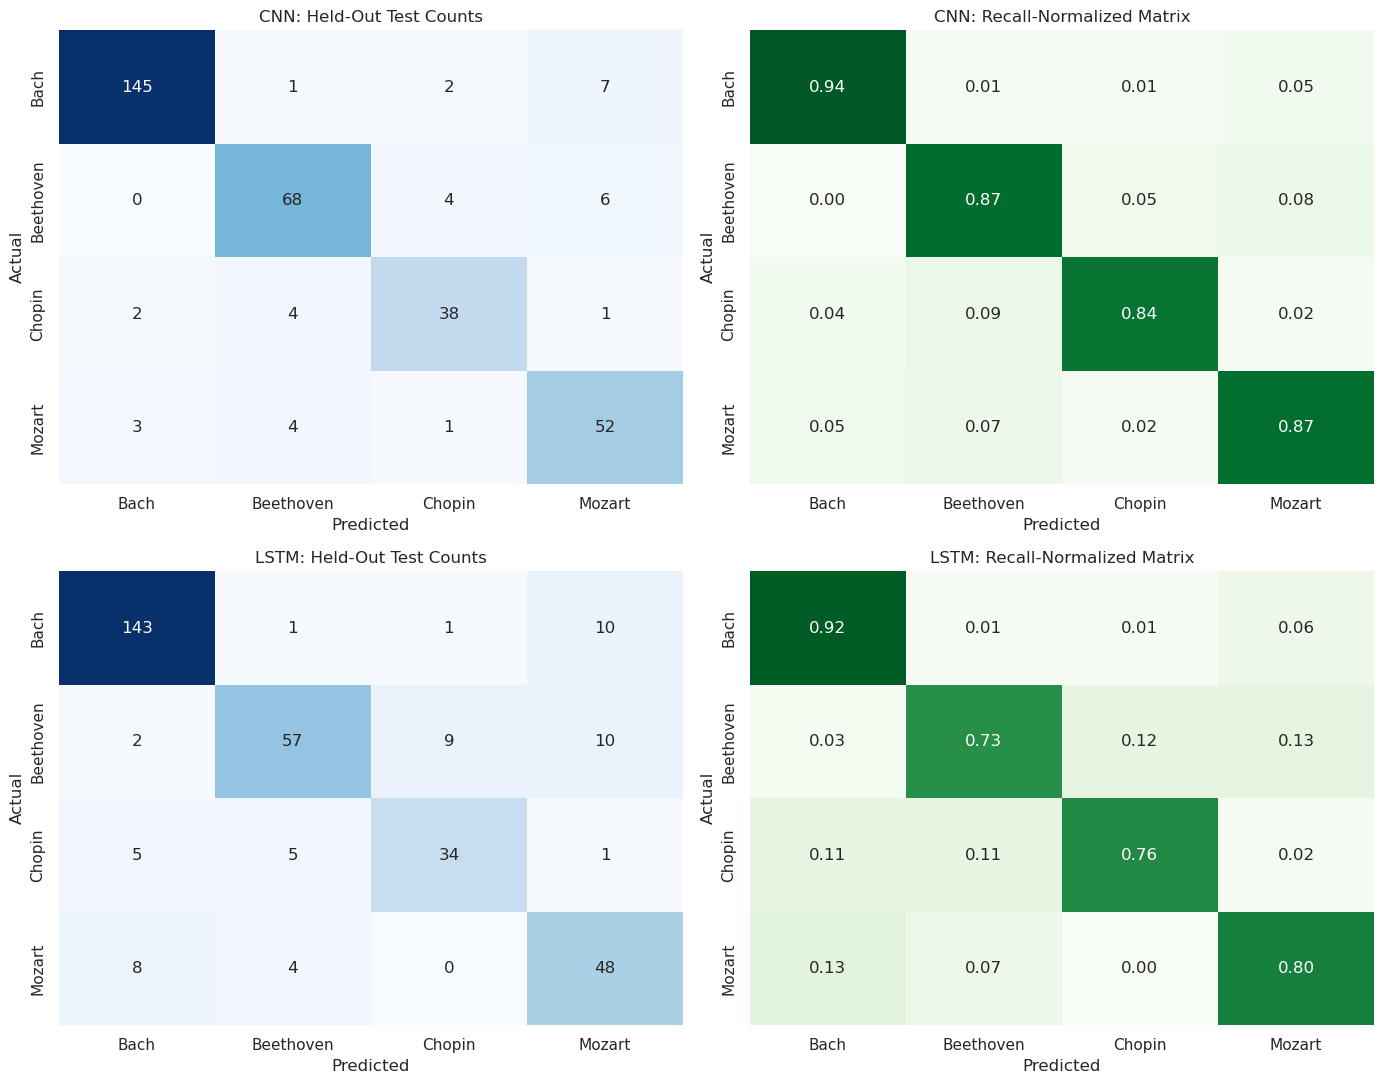

In [13]:
metrics_df.to_csv(ARTIFACT_DIR / "held_out_test_metrics.csv", index=False)

prediction_df = pd.DataFrame({
    "filename": test_df["filename"].values,
    "relative_path": test_df["relative_path"].values,
    "actual_composer": label_encoder.inverse_transform(y_test),
    "cnn_prediction": label_encoder.inverse_transform(cnn_predictions),
    "cnn_confidence": cnn_probabilities.max(axis=1),
    "lstm_prediction": label_encoder.inverse_transform(lstm_predictions),
    "lstm_confidence": lstm_probabilities.max(axis=1),
})
prediction_df.to_csv(
    ARTIFACT_DIR / "held_out_test_predictions.csv", index=False
)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row, (name, predictions) in enumerate({
    "CNN": cnn_predictions, "LSTM": lstm_predictions
}.items()):
    raw = confusion_matrix(y_test, predictions, labels=class_ids)
    normalized = confusion_matrix(
        y_test, predictions, labels=class_ids, normalize="true"
    )
    sns.heatmap(
        raw, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=axes[row, 0],
    )
    axes[row, 0].set(
        title=f"{name}: Held-Out Test Counts",
        xlabel="Predicted", ylabel="Actual",
    )
    sns.heatmap(
        normalized, annot=True, fmt=".2f", cmap="Greens",
        vmin=0, vmax=1, cbar=False,
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=axes[row, 1],
    )
    axes[row, 1].set(
        title=f"{name}: Recall-Normalized Matrix",
        xlabel="Predicted", ylabel="Actual",
    )
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrices.png", dpi=180)
plt.show()

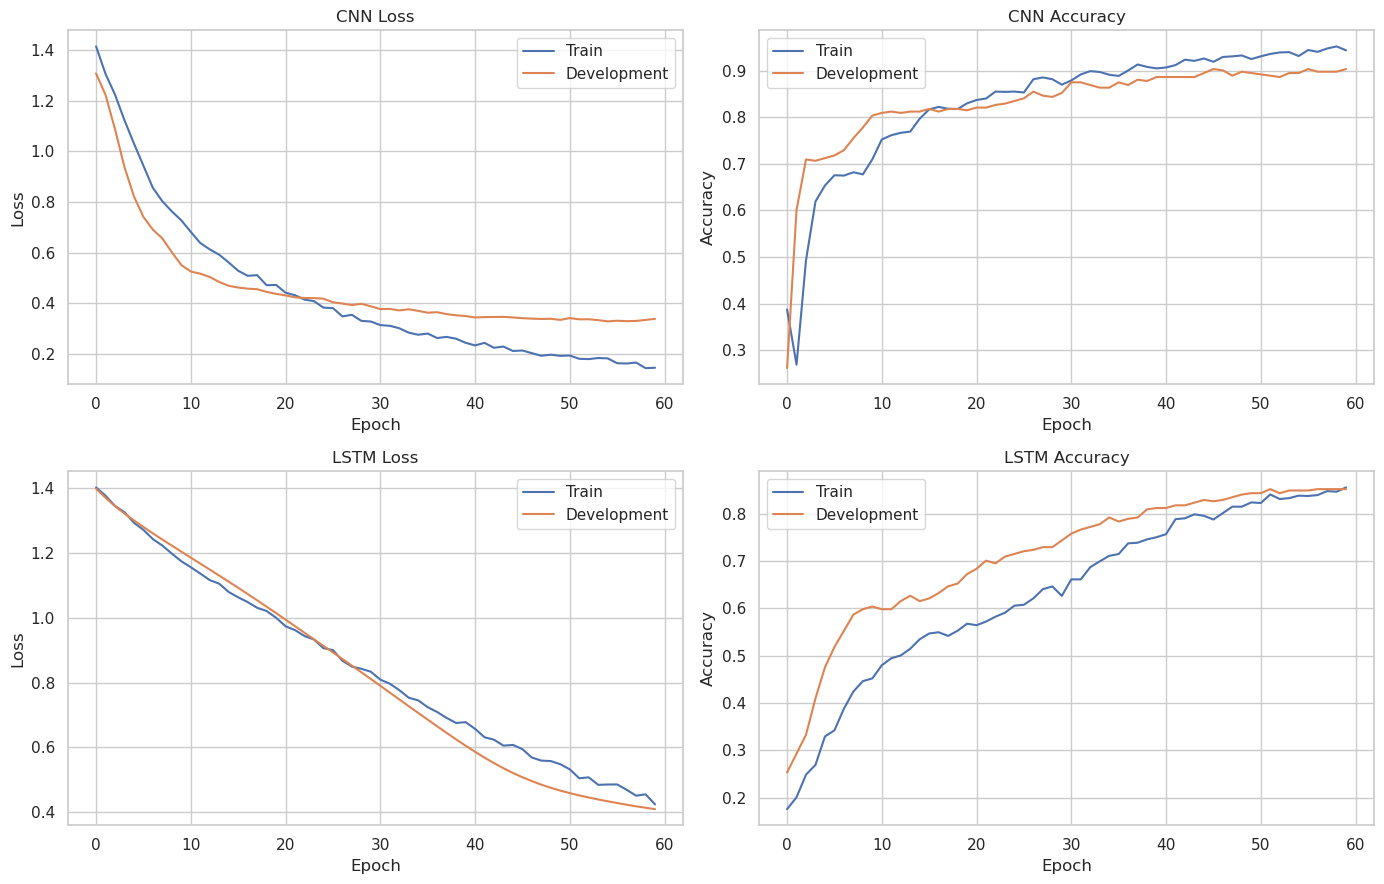

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (name, history) in enumerate({
    "CNN": cnn_history, "LSTM": lstm_history
}.items()):
    axes[row, 0].plot(history.history["loss"], label="Train")
    axes[row, 0].plot(history.history["val_loss"], label="Development")
    axes[row, 0].set(title=f"{name} Loss", xlabel="Epoch", ylabel="Loss")
    axes[row, 0].legend()

    axes[row, 1].plot(history.history["accuracy"], label="Train")
    axes[row, 1].plot(history.history["val_accuracy"], label="Development")
    axes[row, 1].set(
        title=f"{name} Accuracy", xlabel="Epoch", ylabel="Accuracy"
    )
    axes[row, 1].legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "training_curves.png", dpi=180)
plt.show()

## Verified Reference Results

The models were trained and evaluated on the combined_train_features.csv, combined_dev_features.csv & combined_test_features.csv compositions files before this notebook was packaged.

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|---:|
| LSTM | 0.855 | 0.829 | 0.830 | 0.827 | 0.856 |
| CNN | 0.846 | 0.813 | 0.821 | 0.816 | 0.848 |

The LSTM produced the stronger held-out performance, exceeding the CNN by 0.9 percentage points in accuracy and 1.1 points in macro F1. Both models showed good generalization, but their interpretation should remain tied to aggregate composition-level features. 

A future temporal LSTM should use ordered note or beat sequences extracted directly from each MIDI file.